# Notebook 2: 02_Historical_Hotspot_Intelligence

This notebook mines the cleaned data to establish the structural baseline of the city's traffic. We generate a spatial grid, calculate historical recurrence, aggregate the Congestion Impact Index, and engineer the foundational `Historical Risk Score`.

### Cell 1: Setup & Data Ingestion

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Loading Cleaned Foundation Data...")

# Load the parquet file generated in Notebook 1
CLEANED_DATA_PATH = "data/processed/cleaned_dataset.parquet"
try:
    df = pd.read_parquet(CLEANED_DATA_PATH)
    print(f"✅ Successfully loaded {len(df)} records.")
except FileNotFoundError:
    print("❌ Error: cleaned_dataset.parquet not found. Please run Notebook 1 first.")

Loading Cleaned Foundation Data...
✅ Successfully loaded 184411 records.


### Cell 2: Micro-Grid Generation
To analyze the city systematically, we chunk the continuous GPS coordinates into discrete spatial bins (roughly ~100x100 meter micro-grids).

In [ ]:
print("Generating Spatial Micro-Grid...")

# Rounding latitude/longitude to 3 decimal places creates a grid of approx 110m x 110m
df["grid_lat"] = df["latitude"].round(3)
df["grid_lon"] = df["longitude"].round(3)

unique_grids = df[["grid_lat", "grid_lon"]].drop_duplicates()
print(f"✅ City mapped into {len(unique_grids)} unique micro-grid blocks.")

Generating Spatial Micro-Grid...
✅ City mapped into 7613 unique micro-grid blocks.


### Cell 3: Recurrence & Impact Aggregation
We calculate how many unique days a grid block experienced gridlock, and the average severity of the vehicles causing it.

In [ ]:
print("Aggregating Historical Intelligence...")

total_days_in_dataset = df["date"].nunique()

# Group by the spatial grid
grid_stats = df.groupby(["grid_lat", "grid_lon"]).agg(
    total_violations=("device_id", "count"),
    unique_days_active=("date", "nunique"),
    avg_base_impact=("base_impact_score", "mean"),
    max_base_impact=("base_impact_score", "max")
).reset_index()

# 1. Recurrence Rate: What percentage of days was this a problem?
grid_stats["recurrence_rate"] = grid_stats["unique_days_active"] / total_days_in_dataset

print("✅ Recurrence and Impact aggregated.")
display(grid_stats.sort_values("total_violations", ascending=False).head(5))

Aggregating Historical Intelligence...
✅ Recurrence and Impact aggregated.


,grid_lat,grid_lon,total_violations,unique_days_active,avg_base_impact,max_base_impact,recurrence_rate
4262,12.981,77.610,2697,149,30.470894,50.0,0.986755
3097,12.964,77.577,2100,149,27.414286,50.0,0.986755
3958,12.977,77.576,2078,145,27.064485,70.0,0.960265
7156,13.071,77.588,1511,114,12.217075,25.0,0.754967
1724,12.934,77.691,1474,84,12.486431,25.0,0.556291


### Cell 4: The Historical Risk Score
We combine volume, recurrence, and physical impact into a single normalized score (0-100). This will serve as the $R_{hist}$ variable in our final Streamlit dashboard.

In [ ]:
print("Engineering Baseline Risk Score...")

# The raw hazard score multiplies how OFTEN it happens by how BAD it is when it happens
grid_stats["raw_hazard"] = grid_stats["total_violations"] * grid_stats["recurrence_rate"] * grid_stats["avg_base_impact"]

# Log transform to handle extreme outliers (like Majestic or Silk Board)
grid_stats["log_hazard"] = np.log1p(grid_stats["raw_hazard"])

# Min-Max Scaling to a clean 0-100 range
min_hazard = grid_stats["log_hazard"].min()
max_hazard = grid_stats["log_hazard"].max()

grid_stats["historical_risk_score"] = ((grid_stats["log_hazard"] - min_hazard) / (max_hazard - min_hazard)) * 100

# Drop the intermediate math columns to keep the master table clean
grid_stats = grid_stats.drop(columns=["raw_hazard", "log_hazard"])

print("✅ Historical Risk Score (0-100) generated.")

Engineering Baseline Risk Score...
✅ Historical Risk Score (0-100) generated.


### Cell 5: Visualizing the Top Structural Threats

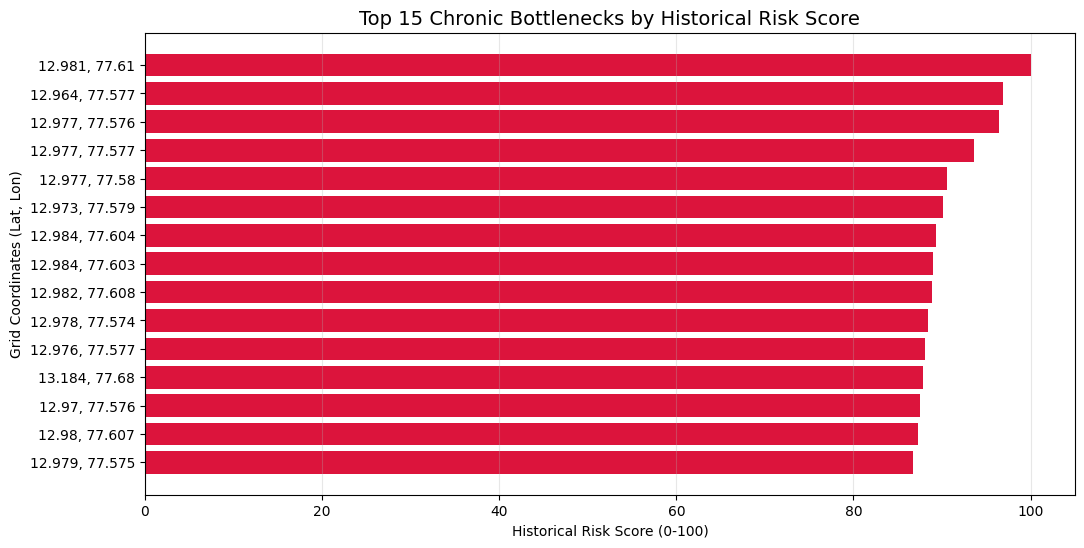

In [ ]:
top_threats = grid_stats.sort_values("historical_risk_score", ascending=False).head(15)

plt.figure(figsize=(12, 6))
bars = plt.barh(range(15), top_threats["historical_risk_score"], color='crimson')

# Formatting the chart
plt.yticks(range(15), [f"{lat}, {lon}" for lat, lon in zip(top_threats['grid_lat'], top_threats['grid_lon'])])
plt.gca().invert_yaxis() # Highest score at the top
plt.title("Top 15 Chronic Bottlenecks by Historical Risk Score", fontsize=14)
plt.xlabel("Historical Risk Score (0-100)")
plt.ylabel("Grid Coordinates (Lat, Lon)")
plt.grid(axis='x', alpha=0.3)
plt.show()

### Cell 6: Exporting the Master Grid

In [ ]:
print("Exporting Historical Intelligence...")

# Save as CSV for quick viewing/dashboarding
grid_stats.to_csv("data/processed/hotspot_history.csv", index=False)

# Merge the grid coordinates back onto the main dataframe for Notebook 3 & 4
df_with_features = df.merge(grid_stats[["grid_lat", "grid_lon", "historical_risk_score"]], on=["grid_lat", "grid_lon"], how="left")
df_with_features.to_parquet("data/processed/hotspot_features.parquet", index=False)

print("🚀 SUCCESS: Historical Baseline complete. Assets saved to data/processed/")

Exporting Historical Intelligence...
🚀 SUCCESS: Historical Baseline complete. Assets saved to data/processed/
